# <span style="color: green;"> Desafío - Tabaquismo y gestación 
 </span>

por Matias Barra

## <span style="color: green;"> 1.</span> Realiza una exploración de los datos, considerando sus tipos y los descriptivos correspondientes

### Exploración de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest, probplot, norm, binom


In [3]:
df = pd.read_csv('baby.csv') # Cargamos el archivo Baby.csv
df.head() # primera impresión de los datos

,Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
0,1,120,284,27,62,100,False
1,2,113,282,33,64,135,False
2,3,128,279,28,64,115,True
3,4,108,282,23,67,125,True
4,5,136,286,25,62,93,False


### Tipos y descriptivos

In [4]:
df.info() #vemos como estan constituidos los datos.
df.describe() #Sacamos los Estadisticos.
df['Maternal.Smoker'].value_counts() #aprovechando que es boleano, sacamos el dato directo.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Unnamed: 0                 1174 non-null   int64
 1   Birth.Weight               1174 non-null   int64
 2   Gestational.Days           1174 non-null   int64
 3   Maternal.Age               1174 non-null   int64
 4   Maternal.Height            1174 non-null   int64
 5   Maternal.Pregnancy.Weight  1174 non-null   int64
 6   Maternal.Smoker            1174 non-null   bool 
dtypes: bool(1), int64(6)
memory usage: 56.3 KB


Maternal.Smoker
False    715
True     459
Name: count, dtype: int64

## <span style="color: green;"> 2.</span> Considera los pesos de los bebés. ¿Se puede decir que siguen una distribución normal? Justifica tu respuesta creando los gráficos y modelos necesarios.

Primero, creamos la hipotesis nula y definimos la hipotesis alterniativa.
HIpotesis Nula: Siguen una distribución normal.
Hipotesis Alternativa: No siguen una distribución normal.

### Histograma y KDE

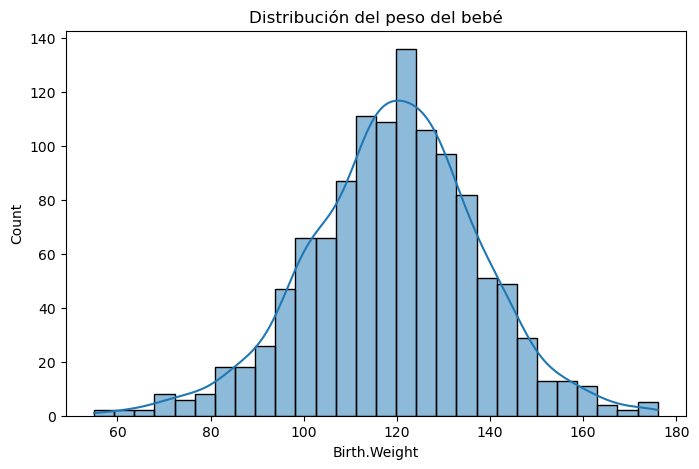

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Birth.Weight'], kde=True) # creamos un histograma para ver su distribucion, aplicamos KDE para ver su forma visual
plt.title("Distribución del peso del bebé")
plt.show()


A primera vista, se puede ver que podrian seguir una distribución normal por la forma del grafico, y la curva que simula la campana de gauss, aunque se pueden ver ciertas osilaciones en la curva de la distribución normal.
por lo que podemos inferir que visualmente pareciera una distribución normal que no es perfecta.

### QQ-Plot

Utilizo tambien el tipo de grafico QQ Plot, el cual compara la distribucion de los datos reales con uno teorico perfecto, en este sentido, crea un conjunto de datos “imaginarios” que seguirían una normal perfecta con la misma media y desviación que los datos reales. 

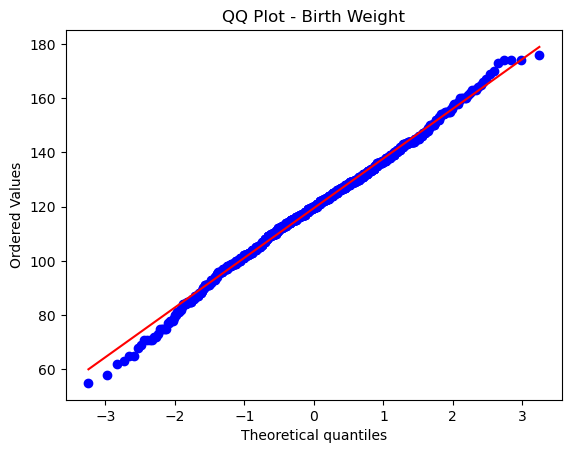

In [6]:
probplot(df['Birth.Weight'], dist="norm", plot=plt)
plt.title("QQ Plot - Birth Weight")
plt.show()


La linea roja representa la normal perfecta, y se puede ver que tanto la cola inferior como la cola superior de los datos reales se arquean un poco, pero no estan tan separados como para rechazar la hipotesis nula. por lo tanto podemos inferir que los datos podrian siguir una distribución normal pero no una perfectamente normal.

### Pruebas de normalidad

In [9]:
normaltest_test = normaltest(df['Birth.Weight'])
normaltest_test

NormaltestResult(statistic=np.float64(10.487179122909025), pvalue=np.float64(0.005281265344188633))

p-value es menor a 0.05 (p-value = 0.005), la hipotesis nula es mucho menor al umbral permitido, por lo que se rechaza la hipotesis nula en el test de normalidad.

### Concluciones
si bien el test de normalidad fallo en los pesos de los bebes, solo indica que no es una distribución normal perfecta. pero sigue siendo una distribución normal, y los datos son lo suficientemente razonable como para usarla como modelo teórico de comparación.

## <span style="color: green;"> 3.</span> Considerando lo anterior, verifica el modelo de distribución normal de los pesos para 5 valores diferentes. Compara con los datos reales.

In [12]:
mu = df['Birth.Weight'].mean() ## media real del peso
sigma = df['Birth.Weight'].std() ## desviasión estandar del peso

valores = [120, 140, 160, 180, 200] ## elijo 5 valores dentro de la curva

modelo = norm.cdf(valores, mu, sigma) #probabilidad normal teorica
real = [(df['Birth.Weight'] <= v).mean() for v in valores] #probabilidad real

pd.DataFrame({ ## creo el dataframe de las probabilidades.
    "Peso": valores,
    "Modelo Normal": modelo,
    "Datos Reales": real
})


,Peso,Modelo Normal,Datos Reales
0,120,0.511697,0.516184
1,140,0.868752,0.884157
2,160,0.986506,0.986371
3,180,0.999522,1.000000
4,200,0.999994,1.000000


Podemos ver que existe una pequeña diferencia en los datos pero se acerca bastante lo mostrado por los datos reales, por lo tanto utilizar el modelo de distribución normal como modelo de comparación podria representar de forma significativa a los datos reales.

## <span style="color: green;"> 4.</span> Compara los pesos de los bebés de madres fumadoras y no fumadoras. ¿Qué diferencias existen? Explica y construye los modelos correspondientes.

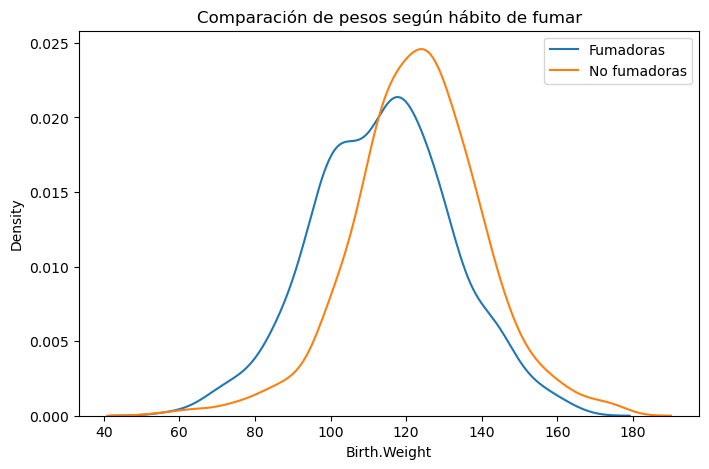

In [14]:
fum = df[df['Maternal.Smoker'] == True]['Birth.Weight'] # aislamos el peso de los pesos de los bebes de madres fumadoras
nofum = df[df['Maternal.Smoker'] == False]['Birth.Weight'] # aislamos el peso de los bebes de las madres no fumadoras

plt.figure(figsize=(8,5))
# curvas de densidad
sns.kdeplot(fum, label="Fumadoras")
sns.kdeplot(nofum, label="No fumadoras")
plt.legend()
plt.title("Comparación de pesos según hábito de fumar")
plt.show()


En el grafico comparamos la curva de densidad de los pesos de los bebes de las madres fumadoras y las no fumadoras.
de esto podemos inferir:
* Las madres no fumadoras tienen bebes de mayor pesos y con una mayor consistencia (curva de densidad casi perfecta sin oscilaciones claras)
* las madres fumadoras tienden a tener bebes de menor peso que las madres no fumaduras, y tambien sus bebes presentan una variación de pesos que hace que su curva de densidad no sea perfecta.


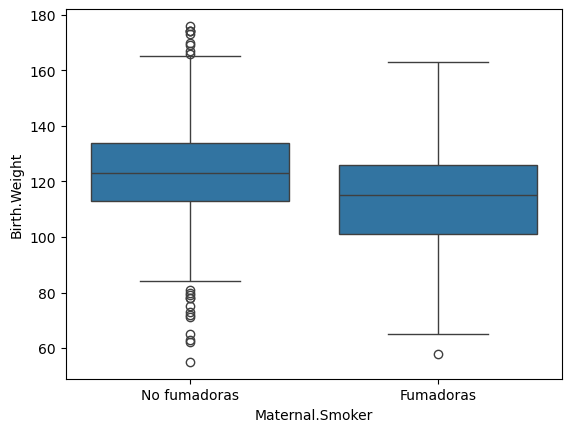

In [15]:
sns.boxplot(x=df['Maternal.Smoker'], y=df['Birth.Weight'])
plt.xticks([0,1], ["No fumadoras", "Fumadoras"])
plt.show()


si bien se pueden ver valores outsider en el grafico de cajas de los no fumadores, podemos observar que la mayor cantidad de datos se concentran en valores mas altos que los datos situados en la misma zona pero en el caso de las madres fumadoras, lo que nos permite inferir que los bebes de madres no fumadoras presentan pesos mas altos que los bebes de madres fumadoras.
los valores outsider del caso de las no fumadoras puede explicarse porel fallo en el test de normalidad que hicimos en el paso 2, pero de todas formas los datos siguen una distribucion normal segun los demas test hechos en esta actividad.

## <span style="color: green;"> 5.</span> Considerando los datos dados:
* Calcula la probabilidad de que una madre escogida al azar fume
* A partir del valor anterior, construye un modelo de distribución binomial quemodele el experimento correspondiente a escoger 5 madres al azar y observar cuántas fuman.
* Utilizando este modelo, simula 1000 muestras de tamaño 8, y calcula sus medias
muestrales.
Utilizando lo anterior:
* compara gráficamente los resultados obtenidos anteriormente.
* verifica el teorema del límite central, considerando las muestras de datos reales y las simuladas con el modelo binomial.
* construye un modelo de distribución normal derivado del modelo binomial, y grafícalo junto a los anteriores para comparar.
* Concluye.





### Probabilidad de que una madre fume

In [16]:
p_fuma = df['Maternal.Smoker'].mean()
p_fuma


np.float64(0.3909710391822828)

### Modelo binomial para 5 madres

In [17]:
n = 5
prob = p_fuma

x = np.arange(0, 6)
pmf = binom.pmf(x, n, prob)

pd.DataFrame({"x": x, "P(X=x)": pmf})


,x,P(X=x)
0,0,0.083790
1,1,0.268947
2,2,0.345305
3,3,0.221671
4,4,0.071152
5,5,0.009135


x representa la cantidad de madres que fuman y P(X=x) representa la probabilidad de suceso.
en este caso se puede apreciar que si tomamos 5 madres al azar, resulta ser mas probable que almenos 2 fumen, y menos probable que las 5 escogidas fumen.

### Simular 1000 muestras de tamaño 8 (binomial)

In [26]:
sim_binomial = [binom.rvs(8, prob) / 8 for _ in range(1000)] 
# crear la poblacion de 1000 simulaciones al escoger 8 madres al azar.


In [27]:
sim_real = []

for _ in range(1000): #simular 1000 veces tomar 8 madres al azar en los datos reales
    muestra = df['Maternal.Smoker'].sample(8, replace=True)
    sim_real.append(muestra.mean()) #promedio de la poblacion real


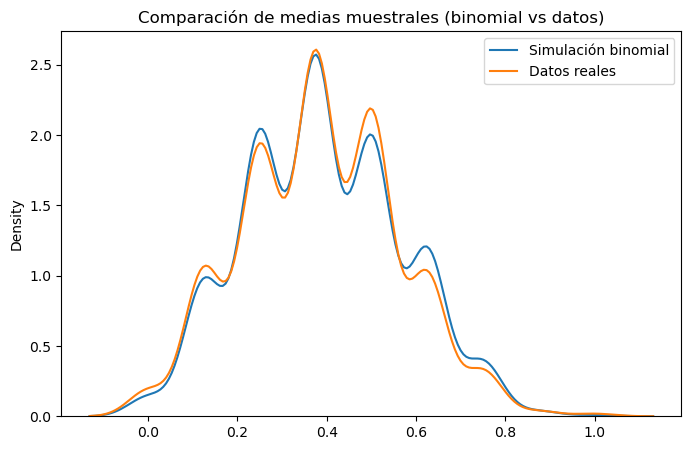

In [28]:
plt.figure(figsize=(8,5))
sns.kdeplot(sim_binomial, label="Simulación binomial")
sns.kdeplot(sim_real, label="Datos reales")
plt.legend()
plt.title("Comparación de medias muestrales (binomial vs datos)")
plt.show()


Ambos graficos (simulacion en los casos de datos reales y el caso de los datos creados a travéz de la distribucíon binomial) se asemejan entre si, podemos ver que las proporciones mas tipicas apuntan a 2,5 madres fumadoras, lo que indica que en estas 1000 simulaciones que hicieron en ambos casos, es mas probable que al menos 2 madres fumen.

### Teorema del Límite Central (TLC)
Los promedios deberían tender a una distribución normal.

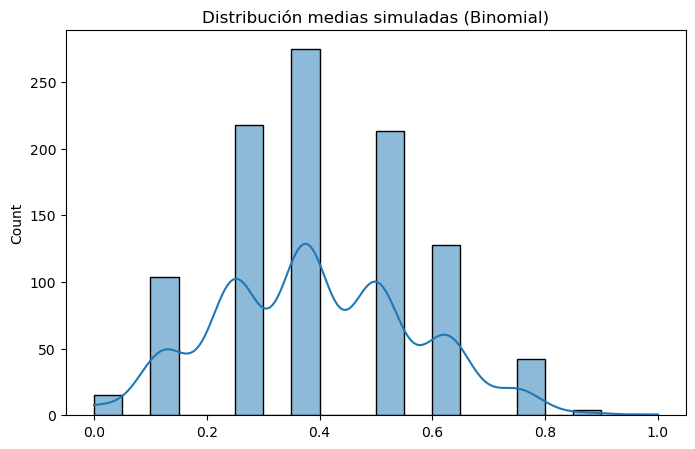

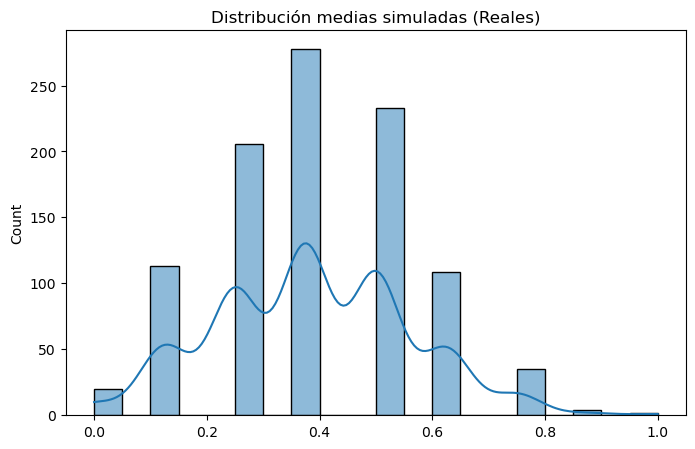

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(sim_binomial, kde=True)
plt.title("Distribución medias simuladas (Binomial)")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(sim_real, kde=True)
plt.title("Distribución medias simuladas (Reales)")
plt.show()


ambas distribuciones de la media se asemejan una distribución normal, lo cual nos ayuda a comprobar de manera visual el teorema del limite central, el cual indica que las medias de muestras suficientemente grandes tienden a ser normales.

### Modelo normal derivado del binomial
Calculamos la normal Teórica que deberia aparecer segun:
* media = p
* varianza = p(1-p)/n
* y graficamos

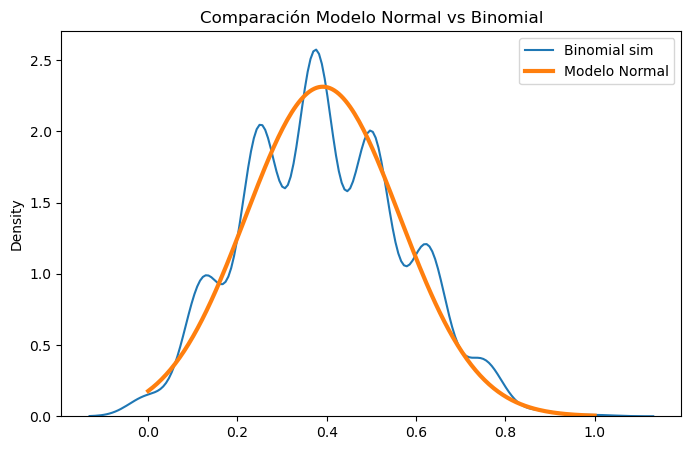

In [31]:
mu_bin = prob #media
sigma_bin = np.sqrt(prob*(1-prob)/8) #varianza

x = np.linspace(min(sim_binomial), max(sim_binomial), 200)
y = norm.pdf(x, mu_bin, sigma_bin)

plt.figure(figsize=(8,5))
sns.kdeplot(sim_binomial, label="Binomial sim")
plt.plot(x, y, label="Modelo Normal", lw=3)
plt.legend()
plt.title("Comparación Modelo Normal vs Binomial")
plt.show()


se puede apreciar que el modelo binomial es representado significativamente por el modelo de distribución normal y que por lo tanto nuestras hipotesis nula de que el modelo es representado por una distribución normal no es rechazado.